#### What is Vocabulory ?
Vocabulory:
>A unique set of tokens in a tokenizer.  vocabulary items can be a characters, sub-words, words, numbers, code, segments, emojis etc.

- Encoder: A function that maps text into integers.
- Decoder: A function (look-up-table) that maps integers into texts.


Lets take a small demonstrative code run to understand how it happens

In [1]:
text = [
    "We are what we repeatedly do. Excellence, then, is not an act, but a habit",
    "In the middle of difficulty lies opportunity",
    "It is never too late to be what you might have been",
    "Do not go where the path may lead, go instead where there is no path and leave a trail",
    "The only way to do great work is to love what you do",
    "You miss 100 percent of the shots you don’t take",
    "Happiness depends upon ourselves",
    "Turn your wounds into wisdom",
    "What we think, we become",
    "Success is not final, failure is not fatal: it is the courage to continue that counts"
]

In [2]:
# lets create a function that takes a list of strings and returns words
vocab = []
for quote in text:
    x = quote.split()
    for y in x:
        vocab.append(y.lower())
vocab = set(vocab)

In [3]:
# encoder is a python dictionary type
vocab2idx={word:i for i,word in enumerate(vocab)}

# decorder converts the index to vocab word
idx2vocab={i:word for i, word in enumerate(vocab)}

In [4]:
# vocab2idx
# idx2vocab

In [11]:
# select random words from dictionary
import numpy as np
randindx = np.random.randint(0,len(vocab),size=8)
randomwords = [idx2vocab[i] for i in randindx]

sentence = ' '.join(randomwords)

In [12]:
sentence

'lead, excellence, have path work percent 100 the'

- Basically we can split the text into words via spaces (this does not happen in real tokenization)
- Encoder and decoder funcetions are simple look-up tables
- Tokenisation (encoding text using integers) is conceptually straightforward.

Real models use:

- BPE (Byte Pair Encoding)
- WordPiece
- SentencePiece

Encoder and Decoder are mappings

In [13]:
def myencoder(text_input: str) -> list:
    """Return encoded integers for a text input."""
    try:
        encodedas = [vocab2idx[word] for word in text_input.lower().split()]
        return encodedas
    except KeyError:
        print('This is no index for words')

In [16]:
myencoder(sentence)

[2, 67, 56, 9, 53, 19, 34, 54]

In [17]:
def mydecoder(token_idxes: list) -> list:
    """Return encoded integers for a text input."""
    try:
        decodedas = [idx2vocab[idx] for idx in token_idxes]
        return decodedas
    except KeyError:
        print('This is no index for words')

In [18]:
idxes = [8,7]
mydecoder(idxes)

['into', 'that']

In [19]:
mydecoder(myencoder(sentence))

['lead,', 'excellence,', 'have', 'path', 'work', 'percent', '100', 'the']

Visualize the Vocab

In [25]:
alltext = ' '.join(text) # we joined all the text
tokensall = myencoder(alltext)

In [76]:
from matplotlib import pyplot as plt

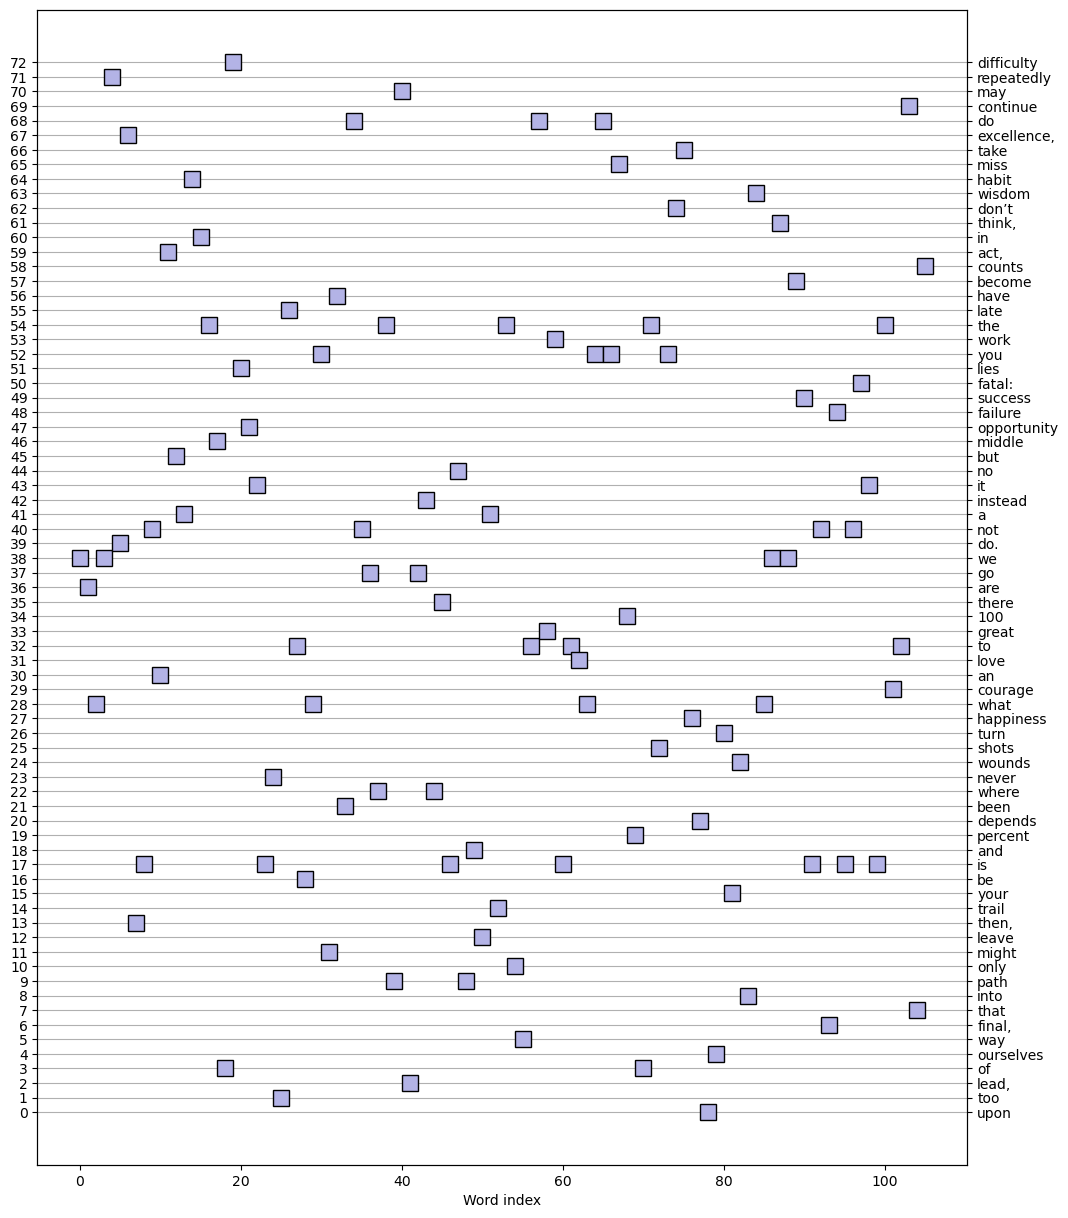

In [49]:
_, ax = plt.subplots(1,figsize=(12,15))
ax.plot(tokensall,'ks',markersize=12,markerfacecolor=[.7,.7,.9])
ax.set(xlabel='Word index',yticks=range(len(vocab)))
ax.grid(linestyle='-',axis='y')

# invisible axis for right-hand-side labels
ax2 =ax.twinx()
ax2.plot(tokensall,alpha=0)
ax2.set(yticks=range(len(vocab)),yticklabels=vocab)

plt.show()

Explore context surrounding target tokens

Finding context surrounding target tokens is not easy as real-world tokenization scheme includes character, subword and full word.


Context in natural language processing is the token before and after the target token

- Find all indices of 'to' (in the text)
- Print each taget and its context

In [56]:
def findtarget(target: str, source: str):
    sourcelist = source.lower().split()
    targets2idxes = {i: word for i, word in enumerate(sourcelist) if word == target.lower()}
    return targets2idxes


In [67]:
findtarget('to',alltext)

{27: 'to', 56: 'to', 61: 'to', 102: 'to'}

In [74]:
def targetcontext(target,source):
    sourcelist = source.lower().split()
    targetidxs = findtarget(target,source)
    # context = { print(value) for key,value in targetidxs.items()}
    context = {
    f"{value}:{key}": {
        key - 1: sourcelist[key - 1],
        key + 1: sourcelist[key + 1]
    }
    for key, value in targetidxs.items()
    }
    return context

targetcontext('to', alltext)

{'to:27': {26: 'late', 28: 'be'},
 'to:56': {55: 'way', 57: 'do'},
 'to:61': {60: 'is', 62: 'love'},
 'to:102': {101: 'courage', 103: 'continue'}}

#### One-Hot Encoding

One-hot encoding is a way to represent categorical values (like words or tokens) as vectors of 0s and 1s, where only one position is “hot” (1) and all others are 0.
- columns represents the category or vocab
- row represents item in dataset

In [96]:
alltext = ' '.join(text) # we joined all the text
allwords = alltext.lower().split()

In [101]:
import numpy as np

word_matrix = np.zeros((len(allwords),len(vocab)),dtype=int)
for i,word in enumerate(allwords):
    word_matrix[i,vocab2idx[word]]=1

In [106]:
print(f'One-hot encoding matrix is of size {word_matrix.shape}\n')
print(word_matrix)

One-hot encoding matrix is of size (106, 73)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


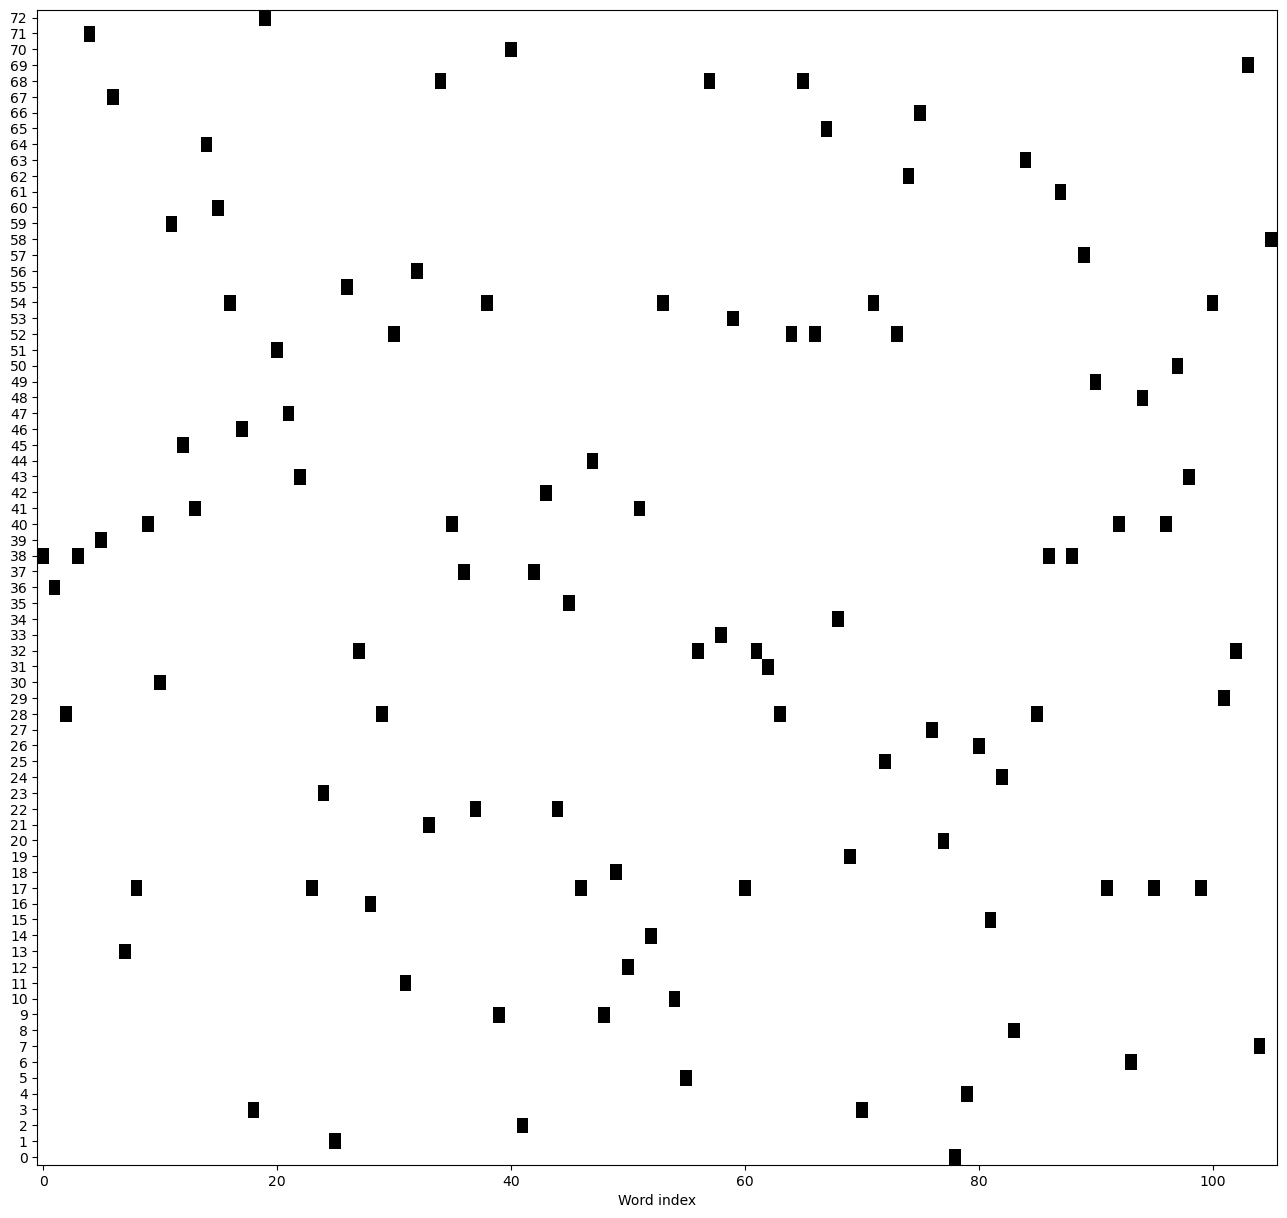

In [115]:
_, ax = plt.subplots(1,figsize=(16,15))
plt.imshow(1-word_matrix.T,cmap='gray',origin='lower',aspect='auto')
ax.set(xlabel='Word index',yticks=range(len(vocab)))
plt.show()